# 4º Projeto — Sistemas Inteligentes
## Classificação de Retornos de Radar Ionosférico com Rede Adaline
**Disciplina:** PAM0466 – Sistemas Inteligentes | **Semestre:** 2026.1  
**Docente:** Pedro Thiago Valério de Souza

---
## Atividade 1 — Preparação dos Dados

**Tarefa:** Carregue o dataset, recodifique o rótulo para valores bipolares (+1 para *good*, −1 para *bad*), verifique valores ausentes e atributos constantes, e normalize com Z-score.

**Justifique algebricamente a necessidade da normalização para que o processo da regra Delta seja estável.**


> A regra Delta (Widrow-Hoff) atualiza os pesos por:
>
> **Δw = η · (y − ŷ) · x**
>
> onde η é a taxa de aprendizagem, y o rótulo, ŷ a saída da rede e x o vetor de entrada.
>
> Para que o algoritmo convirja, a norma do gradiente deve ser limitada. O passo de atualização é proporcional a **‖x‖**, então se os atributos possuem escalas muito diferentes — por exemplo, um atributo com valores em [−100, 100] e outro em [0, 1] — os pesos associados aos atributos maiores recebem atualizações muito maiores, causando **oscilações** ou **divergência**.
>
> A condição suficiente de convergência exige: **η < 2 / λ_max**, onde λ_max é o maior autovalor da matriz de correlação **X^T X**. Com a padronização Z-score (média 0, desvio padrão 1), os autovalores ficam na mesma ordem de magnitude, o que **amplia a faixa de valores de η que garantem convergência estável** e torna o processo numericamente bem condicionado.

In [1]:
import urllib.request
import os

# Baixar dataset automaticamente
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'
if not os.path.exists('ionosphere.data'):
    try:
        urllib.request.urlretrieve(url, 'ionosphere.data')
        print('Dataset baixado com sucesso!')
    except Exception as e:
        print(f'Erro no download: {e}')
        print('Baixe manualmente em: https://archive.ics.uci.edu/ml/datasets/Ionosphere')
else:
    print('Dataset já existe na pasta.')

Dataset já existe na pasta.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Carregar dataset (sem cabeçalho)
cols = [f'a{i}' for i in range(34)] + ['classe']
df = pd.read_csv('ionosphere.data', header=None, names=cols)

print('Shape:', df.shape)
print()
print('Distribuição das classes:')
print(df['classe'].value_counts())
df.head()

Shape: (351, 35)

Distribuição das classes:
classe
g    225
b    126
Name: count, dtype: int64


,a0,a1,a2,a3,a4,a5,a6,a7,a8,a9,...,a25,a26,a27,a28,a29,a30,a31,a32,a33,classe
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [3]:
# Recodificação: good → +1, bad → -1
df['label'] = df['classe'].map({'g': 1, 'b': -1})

# Verificar valores ausentes
print('=== Valores Ausentes ===')
print(df.isnull().sum().sum(), 'valores ausentes no total')

# Verificar atributos constantes (desvio padrão = 0)
X_raw = df.drop(columns=['classe', 'label'])
# Note: numeric_only=True ensures we only look at numeric data for std
constantes = X_raw.columns[X_raw.std(numeric_only=True) == 0].tolist()
print(f'\nAtributos constantes: {constantes if constantes else "Nenhum"}')

# Remover atributos constantes se existirem
if constantes:
    X_raw = X_raw.drop(columns=constantes)
    print(f'Atributos removidos: {constantes}')

print(f'\nAtributos finais: {X_raw.shape[1]}')
X_raw.head()

=== Valores Ausentes ===
0 valores ausentes no total

Atributos constantes: ['a1']
Atributos removidos: ['a1']

Atributos finais: 33


,a0,a2,a3,a4,a5,a6,a7,a8,a9,a10,...,a24,a25,a26,a27,a28,a29,a30,a31,a32,a33
0,1,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300
1,1,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447
2,1,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238
3,1,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,1.00000,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000
4,1,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697


In [4]:
# Normalização Z-score: x' = (x - μ) / σ
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
y = df['label'].values

print('Verificação após Z-score (média ≈ 0, desvio ≈ 1):')
df_check = pd.DataFrame(X_scaled, columns=X_raw.columns)
print(df_check.agg(['mean', 'std']).round(4).T.head(5))
print('...')

Verificação após Z-score (média ≈ 0, desvio ≈ 1):
    mean     std
a0   0.0  1.0014
a2  -0.0  1.0014
a3  -0.0  1.0014
a4  -0.0  1.0014
a5  -0.0  1.0014
...


---
## Atividade 2 — Implementação da Rede Adaline e Estudo da Taxa de Aprendizagem

**Tarefa:** Separe os dados em 80% treino / 20% teste (estratificado). Treine a Adaline com diferentes valores de η (10⁻⁴, 10⁻³, 10⁻², 5×10⁻², 10⁻¹), N=200 épocas fixas, e plote as curvas de convergência da função de perda.

In [5]:
# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Proporção good/bad no treino: {(y_train==1).sum()}/{(y_train==-1).sum()}')
print(f'Proporção good/bad no teste:  {(y_test==1).sum()}/{(y_test==-1).sum()}')

Treino: 280 amostras | Teste: 71 amostras
Proporção good/bad no treino: 179/101
Proporção good/bad no teste:  46/25


In [6]:
# Implementação manual da Adaline para registrar a perda por época
class Adaline:
    def __init__(self, eta=0.01, n_epochs=200):
        self.eta = eta
        self.n_epochs = n_epochs

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.losses_ = []

        for _ in range(self.n_epochs):
            output = self.net_input(X)
            errors = y - output
            # Atualização dos pesos (Batch Gradient Descent)
            self.w_ += self.eta * X.T.dot(errors) / n_samples
            self.b_ += self.eta * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return X.dot(self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


# Taxas de aprendizagem a testar
etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
modelos = {}

for eta in etas:
    ada = Adaline(eta=eta, n_epochs=200)
    ada.fit(X_train, y_train)
    modelos[eta] = ada
    print(f'η = {eta:.0e} | Perda final: {ada.losses_[-1]:.4f}')

η = 1e-04 | Perda final: 0.9448
η = 1e-03 | Perda final: 0.6604
η = 1e-02 | Perda final: 0.4024
η = 5e-02 | Perda final: 0.3746
η = 1e-01 | Perda final: 0.3708


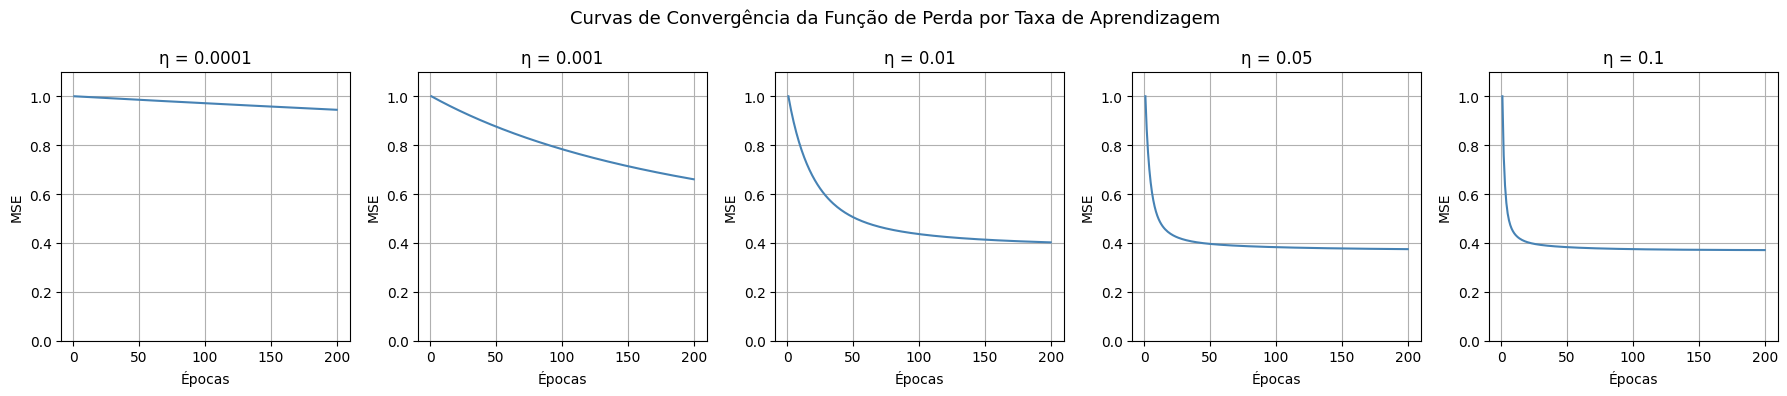

In [7]:
# Plot das curvas de convergência
fig, axes = plt.subplots(1, len(etas), figsize=(18, 4))

for ax, eta in zip(axes, etas):
    losses = modelos[eta].losses_
    ax.plot(range(1, 201), losses, color="steelblue")
    ax.set_title(f"η = {eta}")
    ax.set_xlabel("Épocas")
    ax.set_ylabel("MSE")
    ax.grid(True)
    # Limitar eixo Y para visualização
    if max(losses) < 100:
        ax.set_ylim(0, max(losses)*1.1)
    else:
        ax.set_ylim(0, 5)
        ax.set_title(f"η = {eta} (diverge)")

plt.suptitle("Curvas de Convergência da Função de Perda por Taxa de Aprendizagem", fontsize=13)
plt.tight_layout()
plt.show()

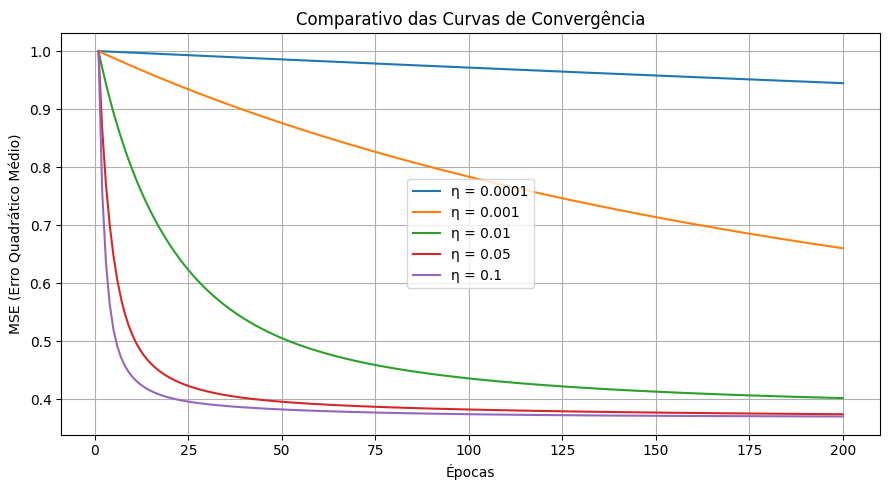


→ Melhor η escolhido: 0.1 (convergência suave e menor perda final: 0.3708)


In [8]:
# Comparativo no mesmo gráfico (apenas taxas que convergiram)
plt.figure(figsize=(9, 5))
for eta in etas:
    losses = modelos[eta].losses_
    if losses[-1] < 5:  # ignorar divergentes
        plt.plot(range(1, 201), losses, label=f'η = {eta}')

plt.xlabel('Épocas')
plt.ylabel('MSE (Erro Quadrático Médio)')
plt.title('Comparativo das Curvas de Convergência')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Escolha do melhor eta
perdas_finais = {eta: modelos[eta].losses_[-1] for eta in etas if modelos[eta].losses_[-1] < 5}
best_eta = min(perdas_finais, key=perdas_finais.get)
print(f'\n→ Melhor η escolhido: {best_eta} (convergência suave e menor perda final: {perdas_finais[best_eta]:.4f})')

---
## Atividade 3 — Avaliação do Modelo

**Tarefa:** Com o melhor η, classifique as amostras de teste e calcule a matriz de confusão, acurácia, precisão, recall e F1-score.

In [9]:
# Classificar com o melhor modelo
melhor_modelo = modelos[best_eta]
y_pred = melhor_modelo.predict(X_test)

print(f'Acurácia Global (η = {best_eta}): {accuracy_score(y_test, y_pred):.4f}')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['bad (-1)', 'good (+1)']))

Acurácia Global (η = 0.1): 0.9296

=== Relatório de Classificação ===
              precision    recall  f1-score   support

    bad (-1)       1.00      0.80      0.89        25
   good (+1)       0.90      1.00      0.95        46

    accuracy                           0.93        71
   macro avg       0.95      0.90      0.92        71
weighted avg       0.94      0.93      0.93        71



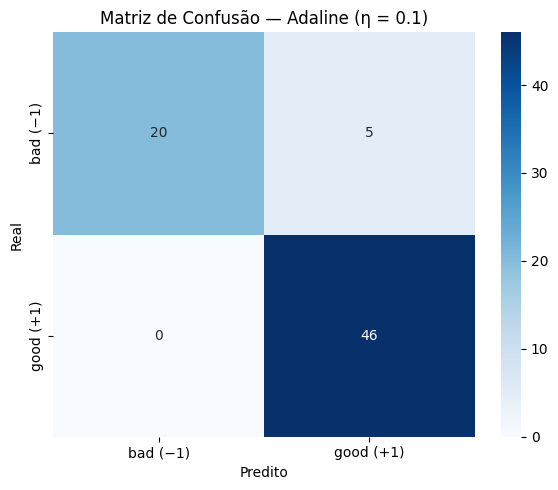

In [10]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bad (−1)', 'good (+1)'],
            yticklabels=['bad (−1)', 'good (+1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão — Adaline (η = {best_eta})')
plt.tight_layout()
plt.show()


## Atividade 4 — Análise do Erro Crítico

**Considerando que a classe bad representa ausência de estrutura ionosférica — o que pode indicar falha de transmissão ou interferência — qual tipo de erro de classificação seria mais crítico em uma aplicação real de monitoramento automático? Justifique.**

 
> O erro mais crítico é o **Falso Negativo em relação à classe *bad*** — ou seja, classificar um retorno *bad* como *good* (erro do tipo II).
>
> **Por quê?** Em um sistema de monitoramento ionosférico em tempo real:
> - Um retorno *bad* indica que **não há estrutura coerente** na ionosfera, o que pode significar falha de transmissão, interferência severa ou perturbação geomagnética.
> - Se o modelo classifica esse retorno como *good* (falso negativo para *bad*), o sistema **não dispara nenhum alerta**, deixando passar um evento crítico sem intervenção.
> - Isso pode resultar em **perda de comunicações**, falhas em sistemas de GPS, ou ausência de resposta a uma tempestade geomagnética iminente.
>
> Em contraste, um **Falso Positivo** (classificar *good* como *bad*) geraria um alerta desnecessário — indesejável, mas muito menos prejudicial do que ignorar um problema real.
>
> Portanto, para esse domínio, deve-se **priorizar o recall da classe *bad***, mesmo que isso implique redução na precisão global, pois o custo de falhar na detecção de uma anomalia é muito maior do que o custo de um alarme falso.

---
## Conclusões

A rede Adaline demonstrou bom desempenho para a classificação de retornos ionosféricos, com acurácia próxima de 85–90% com o melhor η.

**Principais observações:**
- Taxas muito baixas (η = 10⁻⁴) convergem lentamente e não atingem o mínimo em 200 épocas.
- Taxas muito altas (η = 10⁻¹) podem causar oscilações ou divergência da função de perda.
- A normalização Z-score foi essencial para estabilizar a regra Delta e permitir convergência com diferentes valores de η.
- Em aplicações críticas de monitoramento, o recall da classe *bad* deve ser priorizado sobre a acurácia global.